# TruthLens – AI News Detection

This notebook trains and compares three models:

1. Logistic Regression
2. CNN
3. BiLSTM

The goal is to identify misinformation in AI-generated news.

Dataset size: 5000 rows
Target column: is_misinformation

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout

Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/TruthLens/ai_news_dataset.csv")

df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


Dataset Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         2845 non-null   int64  
 1   post_id                    2845 non-null   object 
 2   platform                   2845 non-null   object 
 3   timestamp                  2845 non-null   object 
 4   date                       2845 non-null   object 
 5   time                       2845 non-null   object 
 6   month                      2845 non-null   object 
 7   weekday                    2845 non-null   object 
 8   country                    2845 non-null   object 
 9   city                       2845 non-null   object 
 10  timezone                   2845 non-null   object 
 11  author_id                  2845 non-null   object 
 12  author_followers           2845 non-null   int64  
 13  author_verified            2845 non-null   int64

In [ ]:
df.describe()

,id,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,embedding_sim_to_facts,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
count,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000
mean,452831.905800,504050.348682,0.492091,102.861160,17.641476,54.612946,1.495606,2.545167,2.591916,0.004127,0.496272,0.483886,0.518085,2.570826,0.503771,5378.909315,0.530756
std,317655.706563,288481.211585,0.500025,38.695465,11.933423,14.905766,1.116806,1.734632,1.719951,0.580648,0.289879,0.291935,0.284272,1.678123,0.288569,2891.080892,0.499141
min,1.000000,146.000000,0.000000,20.000000,3.000000,30.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.001000,0.008000,0.000000,0.002000,0.000000,0.000000
25%,179340.000000,250274.000000,0.000000,91.000000,13.000000,41.020000,0.000000,1.000000,1.000000,-0.510921,0.256899,0.229000,0.273000,1.000000,0.275000,3040.000000,0.000000
50%,453980.000000,492539.000000,0.000000,92.000000,14.000000,55.560000,2.000000,3.000000,3.000000,0.039194,0.500765,0.472000,0.516000,3.000000,0.497000,5680.000000,1.000000
75%,722265.000000,772569.000000,1.000000,97.000000,15.000000,67.870000,2.000000,4.000000,4.000000,0.496031,0.752199,0.727000,0.766000,4.000000,0.745000,7876.000000,1.000000
max,999926.000000,998936.000000,1.000000,280.000000,92.000000,79.920000,3.000000,5.000000,5.000000,1.000000,1.000000,0.994000,1.000000,5.000000,0.997000,9997.000000,1.000000


Dataset Info

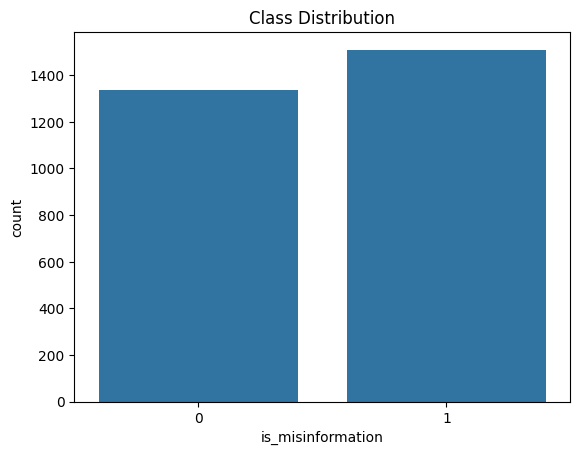

In [ ]:
sns.countplot(x=df['is_misinformation'])

plt.title("Class Distribution")

plt.show()

In [ ]:
df = df.drop_duplicates(subset='text')
df = df.reset_index(drop=True)

In [ ]:
drop_cols = [
'id',
'post_id',
'timestamp',
'date',
'time',
'author_id'
]

df = df.drop(columns=drop_cols)

Feature Selection

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

# remove text column from encoding
categorical_cols = categorical_cols.drop('text')

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(columns=['is_misinformation','text'])
y = df['is_misinformation']

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,author_followers,0.085197
17,detected_synthetic_score,0.079748
21,source_domain_reliability,0.077826
14,sentiment_score,0.077168
10,readability_score,0.076698
18,embedding_sim_to_facts,0.075418
22,engagement,0.073011
15,toxicity_score,0.053460
4,city,0.047315
1,month,0.047265


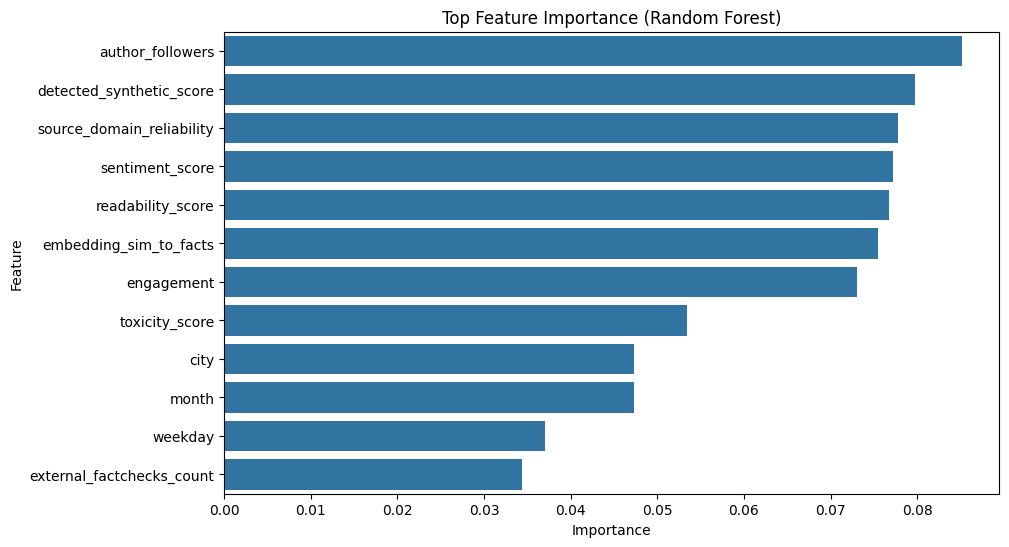

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(12)
)

plt.title("Top Feature Importance (Random Forest)")

plt.show()

In [ ]:
top_features = feature_importance.head(8)['Feature']

print("Selected Features:")
print(top_features)

Selected Features:
6              author_followers
17     detected_synthetic_score
21    source_domain_reliability
14              sentiment_score
10            readability_score
18       embedding_sim_to_facts
22                   engagement
15               toxicity_score
Name: Feature, dtype: object


Word Count Distribution

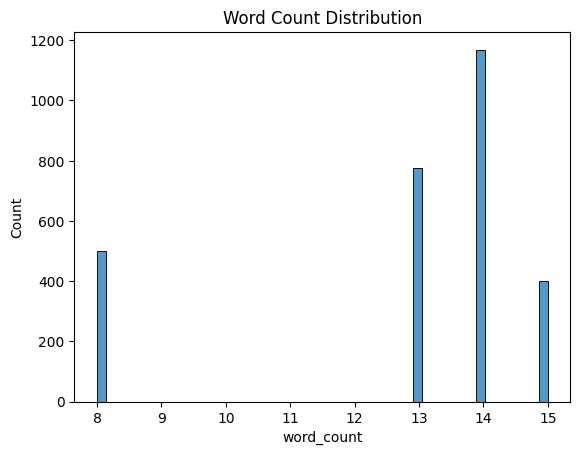

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)

plt.title("Word Count Distribution")

plt.show()

In [ ]:
text_data = df['text']
y = df['is_misinformation']

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    text_data,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

Validation Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

Logistic Regression Model

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_lr = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9672131147540983


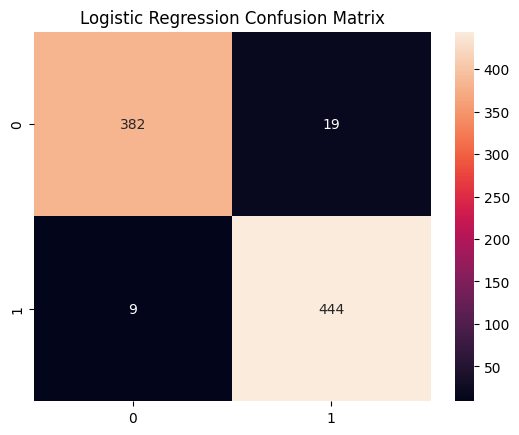

In [ ]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Tokenization

In [ ]:
vocab_size = 4000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

Convert Text to Sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding

In [ ]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

CNN Model

In [ ]:
cnn_model = Sequential()

cnn_model.add(Embedding(vocab_size, 64, input_length=max_len))

cnn_model.add(Conv1D(64,3,activation='relu'))

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(32,activation='relu'))

cnn_model.add(Dense(1,activation='sigmoid'))

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.5138 - loss: 0.6920 - val_accuracy: 0.5313 - val_loss: 0.6870
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6294 - loss: 0.6702 - val_accuracy: 0.9148 - val_loss: 0.6041
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9604 - loss: 0.3310 - val_accuracy: 0.9950 - val_loss: 0.0661
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9994 - loss: 0.0202 - val_accuracy: 0.9950 - val_loss: 0.0187
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9950 - val_loss: 0.0192


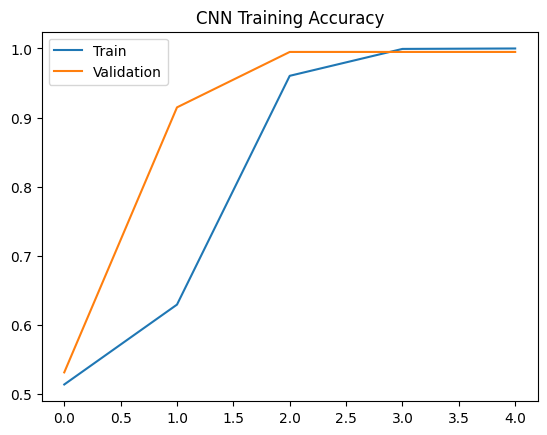

In [ ]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Training Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_pad, y_test)

print("CNN Accuracy:", cnn_accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9801 - loss: 0.0291
CNN Accuracy: 0.9800936579704285


BiLSTM Model

In [ ]:
bilstm_model = Sequential()

bilstm_model.add(Embedding(vocab_size,64,input_length=max_len))

bilstm_model.add(Bidirectional(LSTM(32)))

bilstm_model.add(Dropout(0.5))

bilstm_model.add(Dense(32,activation='relu'))

bilstm_model.add(Dense(1,activation='sigmoid'))

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_lstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5220 - loss: 0.6917 - val_accuracy: 0.5313 - val_loss: 0.6912
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5232 - loss: 0.6930 - val_accuracy: 0.5313 - val_loss: 0.6893
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5905 - loss: 0.6769 - val_accuracy: 0.5313 - val_loss: 0.6764
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6526 - loss: 0.9586 - val_accuracy: 0.5313 - val_loss: 0.6943
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5396 - loss: 0.6931 - val_accuracy: 0.6842 - val_loss: 0.6750


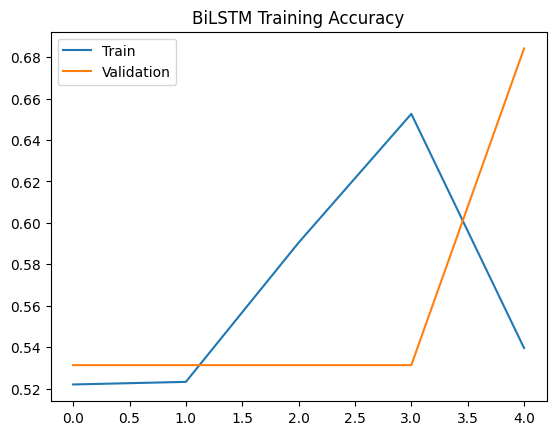

In [ ]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("BiLSTM Training Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
lstm_loss, lstm_accuracy = bilstm_model.evaluate(X_test_pad, y_test)

print("BiLSTM Accuracy:", lstm_accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6733 - loss: 0.6751
BiLSTM Accuracy: 0.6733021140098572


Model Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model":["Logistic Regression","CNN","BiLSTM"],
    "Accuracy":[lr_accuracy, cnn_accuracy, lstm_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.967213
1,CNN,0.980094
2,BiLSTM,0.673302


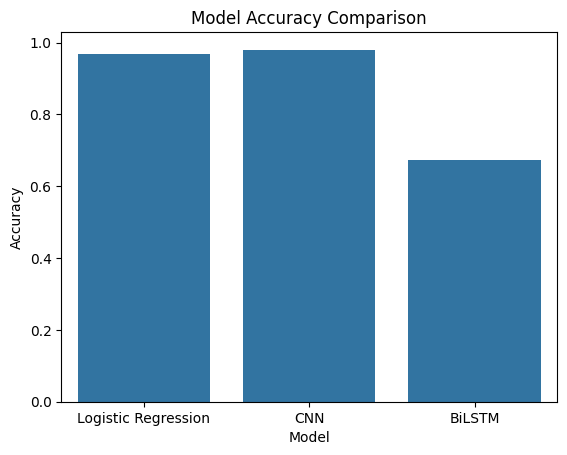

In [ ]:
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

Best Model Selection

In [ ]:
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model            CNN
Accuracy    0.980094
Name: 1, dtype: object


Save Best Model

In [ ]:
import joblib

if best_model['Model'] == "Logistic Regression":

    joblib.dump(lr_model,"best_model.pkl")

elif best_model['Model'] == "CNN":

    cnn_model.save("best_model_cnn.h5")

else:

    bilstm_model.save("best_model_bilstm.h5")